In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
import SpatialGlue

In [2]:
from SpatialGlue.preprocess import fix_seed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.environ['R_HOME'] = '/home/dbj/anaconda3/envs/r/lib/R'
random_seed = 2022
fix_seed(random_seed)

In [3]:
from SpatialGlue.preprocess import clr_normalize_each_cell, pca, lsi

In [4]:
file_fold = '/home/dbj/mouse/SpatialGlue/Mouse_Brain/' #please replace 'file_fold' with the download path

adata1 = sc.read_h5ad(file_fold + 'adata_RNA.h5ad')
adata2 = sc.read_h5ad(file_fold + 'adata_peaks_normalized.h5ad')
adata1.var_names_make_unique()
adata2.var_names_make_unique()
sc.pp.filter_genes(adata1, min_cells=10)
sc.pp.filter_cells(adata1, min_genes=200)
sc.pp.highly_variable_genes(adata1, flavor="seurat_v3", n_top_genes=3000)
adata1 =  adata1[:, adata1.var['highly_variable']]
sc.pp.normalize_total(adata1, target_sum=1e4)
sc.pp.log1p(adata1)
sc.pp.scale(adata1)
adata1.obsm['feat'] = pca(adata1, n_comps=50)

adata2 = adata2[adata1.obs_names].copy()
if 'X_lsi' not in adata2.obsm.keys():
    sc.pp.highly_variable_genes(adata2, flavor="seurat_v3", n_top_genes=3000)
    lsi(adata2, use_highly_variable=False, n_components=51)
adata2.obsm['feat'] = adata2.obsm['X_lsi'].copy()

/home/dbj/anaconda3/envs/SpatialGlue/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [5]:
data_type = 'Spatial-epigenome-transcriptome'

In [6]:
from SpatialGlue.preprocess import construct_neighbor_graph
data = construct_neighbor_graph(adata1, adata2, datatype=data_type)

In [7]:
from SpatialGlue.SpatialGlue_pyG import Train_SpatialGlue
model = Train_SpatialGlue(data, datatype=data_type, device=device)

# train model
output = model.train()

/home/dbj/anaconda3/envs/SpatialGlue/lib/python3.8/site-packages/SpatialGlue/preprocess.py:132: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:641.)
  return torch.sparse.FloatTensor(indices, values, shape)
  0%|                                                                                                                                                                                                                                                                                                                                           | 0/1600 [00:00<?, ?it/s]/home/dbj/anaconda3/envs/SpatialGlue/lib/python3.8/site-packages/SpatialGlue/model.py:212: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  self.alpha = F.softmax(torch.squeeze(

Model training finished!



In [12]:
adata = adata1.copy()
adata.obsm['emb_latent_omics1'] = output['emb_latent_omics1']
adata.obsm['emb_latent_omics2'] = output['emb_latent_omics2']
adata.obsm['SpatialGlue'] = output['SpatialGlue']
adata.obsm['alpha'] = output['alpha']
adata.obsm['alpha_omics1'] = output['alpha_omics1']
adata.obsm['alpha_omics2'] = output['alpha_omics2']

In [13]:
from SpatialGlue.utils import clustering
tool = 'mclust' # mclust, leiden, and louvain
clustering(adata, key='SpatialGlue', add_key='SpatialGlue', n_clusters=18, method=tool, use_pca=True)

fitting ...
  |======================================================================| 100%


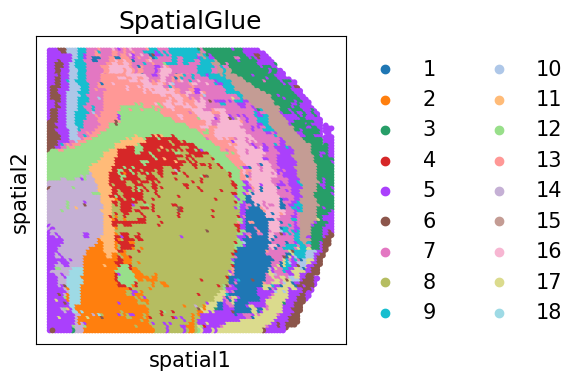

In [14]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams['font.size'] = 15

fig, ax = plt.subplots()
sc.pl.embedding(adata,basis='spatial',color='SpatialGlue',size=70,ax=ax)

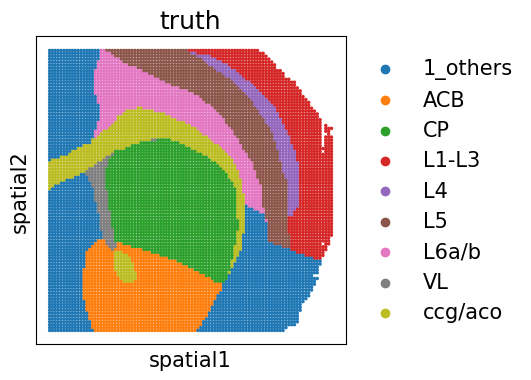

In [15]:
adata2=sc.read_h5ad('/home/dbj/mouse/spatialglue_alldata/Dataset7_Mouse_Brain_ATAC/3d-OT.h5ad')
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams['font.size'] = 15

fig, ax = plt.subplots()
sc.pl.embedding(adata2,basis='spatial',color='truth',size=25,ax=ax)

In [16]:
adata=adata[adata.obs_names.isin(adata2.obs_names)]

In [17]:
import numpy as np
from sklearn.metrics import (homogeneity_score,mutual_info_score,v_measure_score,adjusted_mutual_info_score,normalized_mutual_info_score,adjusted_rand_score
)

true_labels = np.array(adata2.obs['truth'])
cluster_labels = np.array(adata.obs['SpatialGlue'])

homogeneity = homogeneity_score(true_labels, cluster_labels)
mutual_info = mutual_info_score(true_labels, cluster_labels)
v_measure = v_measure_score(true_labels, cluster_labels)
ami = adjusted_mutual_info_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("Homogeneity:", homogeneity)
print("Mutual Information:", mutual_info)
print("V-Measure:", v_measure)
print("AMI:", ami)
print("NMI:", nmi)
print("ARI:", ari)

Homogeneity: 0.6181115793077304
Mutual Information: 1.2348751985182773
V-Measure: 0.5295255532581767
AMI: 0.5280083903842359
NMI: 0.5295255532581767
ARI: 0.31999251193368744
